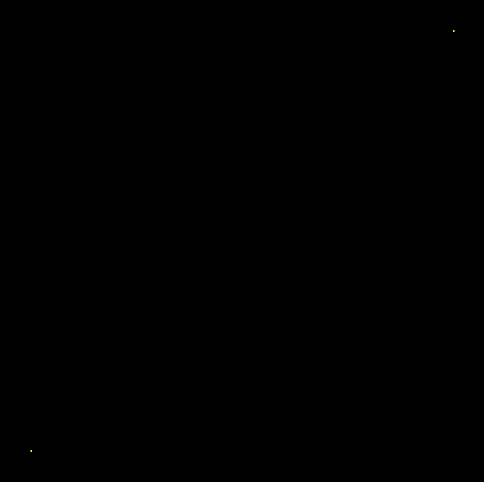

In [15]:
import random
import math
import matplotlib.pyplot as plt
from matplotlib import cm
import numpy as np

found = False
while not found:
    
    # random starting point
    x = random.uniform(-0.5,0.5)
    y = random.uniform(-0.5,0.5)

    # random alternative point nearby
    xe = x + random.uniform(-0.5,0.5) / 1000
    ye = y + random.uniform(-0.5,0.5) / 1000
   

    # distance between the two points
    dx = xe - x
    dy = ye - y
    d0 = math.sqrt(dx*dx + dy*dy)

    # random parameter vector
    a = [random.uniform(-2,2) for i in range(12)]

    # lists
    x_list = [x]
    y_list = [y]

    # initialize convergence boolean and lyapunov exponent
    converging = False
    lyapunov = 0

    # iterate pass (x,y) into quadratic map
    for i in range(1500):
        # compute next point (using the quadratic map)
        xnew = a[0] + a[1]*x + a[2]*x*x + a[3]*y + a[4]*y*y + a[5]*x*y
        ynew = a[6] + a[7]*x + a[8]*x*x + a[9]*y + a[10]*y*y + a[11]*x*y

        # check if we converge to infinity

        if xnew > 1e10 or ynew > 1e10 or xnew < -1e10 or ynew < -1e10:
            converging = True
            break

        # check if we converge to a single point
        if abs(x-xnew) < 1e-10 and abs(y-ynew) < 1e-10:
            converging = True
            break

        # checks for chaotic behavior
        if i > 1000:
            # compute next point (using the quadratic map)
            xenew = a[0] + a[1]*xe + a[2]*xe*xe + a[3]*ye + a[4]*ye*ye + a[5]*xe*ye
            yenew = a[6] + a[7]*xe + a[8]*xe*xe + a[9]*ye + a[10]*ye*ye + a[11]*xe*ye

            # compute distance between two points
            dx = xenew - xe
            dy = ynew - ye
            d = math.sqrt(dx*dx + dy*dy)

            # lyapunov exponent
            lyapunov += math.log(abs(d/d0))

            # rescale the alternative point
            xe = xnew + d0*dx/d
            ye = ynew + d0*dy/d


        # update (x,y)
        x = xnew
        y = ynew

        # store (x,y) in list
        x_list.append(x)
        y_list.append(y)
    
    # if chaotic behavior has been found = true
    if not converging and lyapunov >= 10:
        found = True
colors = cm.plasma(np.linspace(0, 1, len(x_list[100:])))
plt.figure(figsize=(6, 6), facecolor='black')
plt.scatter(x_list[100:], y_list[100:], c=colors, s=0.1, linewidth=0)
plt.axis('off')
plt.gca().set_facecolor('black')  # <- esto pone negro el fondo de los ejes
plt.show()

In [12]:
import random
import math
import matplotlib.pyplot as plt
import os
import csv
from datetime import datetime
from matplotlib import cm
import numpy as np
import json

# carpeta para resultados
folder_name = "exploracion_" + datetime.now().strftime("%Y%m%d_%H%M%S")
os.makedirs(folder_name, exist_ok=True)

def guardar_alta_resolucion(x_list, y_list, a_params, output_folder, nombre="destacado"):
    colors = cm.plasma(np.linspace(0, 1, len(x_list)))
    
    plt.figure(figsize=(10, 10), dpi=600, facecolor='black')
    plt.scatter(x_list, y_list, c=colors, s=0.05, linewidth=0)
    plt.axis('off')
    plt.gca().set_facecolor('black')

    plt.savefig(os.path.join(output_folder, f"{nombre}.png"), bbox_inches='tight', pad_inches=0, facecolor='black')

    
    os.makedirs(output_folder, exist_ok=True)
    plt.savefig(os.path.join(output_folder, f"{nombre}.png"), bbox_inches='tight', pad_inches=0)
    plt.close()

    with open(os.path.join(output_folder, f"{nombre}_parametros.json"), 'w') as f:
        json.dump({
            "parametros": a_params,
            "punto_inicial": [x_list[0], y_list[0]],
        }, f, indent=4)

saved_count = 0
max_experiments = 50
lyapunov_threshold = 10
mejor_lyapunov = -999
mejores_datos = {}

for experiment in range(max_experiments):
    x = random.uniform(-0.5, 0.5)
    y = random.uniform(-0.5, 0.5)
    xe = x + random.uniform(-0.5, 0.5) / 1000
    ye = y + random.uniform(-0.5, 0.5) / 1000
    d0 = math.dist((x, y), (xe, ye))
    a = [random.uniform(-2, 2) for _ in range(12)]
    x_list = [x]
    y_list = [y]
    converging = False
    lyapunov = 0

    for i in range(1500):
        xnew = a[0] + a[1]*x + a[2]*x*x + a[3]*y + a[4]*y*y + a[5]*x*y
        ynew = a[6] + a[7]*x + a[8]*x*x + a[9]*y + a[10]*y*y + a[11]*x*y

        if abs(xnew) > 1e10 or abs(ynew) > 1e10:
            converging = True
            break
        if abs(x - xnew) < 1e-10 and abs(y - ynew) < 1e-10:
            converging = True
            break

        if i > 1000:
            xenew = a[0] + a[1]*xe + a[2]*xe*xe + a[3]*ye + a[4]*ye*ye + a[5]*xe*ye
            yenew = a[6] + a[7]*xe + a[8]*xe*xe + a[9]*ye + a[10]*ye*ye + a[11]*xe*ye
            d = math.dist((xenew, yenew), (xe, ye))
            if d != 0:
                lyapunov += math.log(abs(d / d0))
                xe = xnew + d0 * (xenew - xe) / d
                ye = ynew + d0 * (yenew - ye) / d

        x, y = xnew, ynew
        x_list.append(x)
        y_list.append(y)

    if not converging and lyapunov >= lyapunov_threshold:
        saved_count += 1

        filename = f"chaos_{saved_count:03}"
        colors = cm.plasma(np.linspace(0, 1, len(x_list[100:])))  # o inferno, magma...

        plt.figure(figsize=(6, 6), facecolor='black')
        plt.scatter(x_list[100:], y_list[100:], c=colors, s=0.1, linewidth=0)
        plt.axis('off')
        plt.gca().set_facecolor('black')  # <- esto pone negro el fondo de los ejes

        plt.savefig(os.path.join(folder_name, f"{filename}.png"), dpi=300, bbox_inches='tight', pad_inches=0, facecolor='black')
        plt.close()

        with open(os.path.join(folder_name, f"{filename}.csv"), mode='w', newline='') as f:
            writer = csv.writer(f)
            writer.writerow(['x', 'y'])
            writer.writerows(zip(x_list, y_list))

        print(f"✅ Guardado {filename} con Lyapunov {lyapunov:.2f}")

        # actualiza mejor sistema
        if lyapunov > mejor_lyapunov:
            mejor_lyapunov = lyapunov
            mejores_datos = {
                "x_list": x_list,
                "y_list": y_list,
                "a_params": a
            }


In [7]:
import os, sys
os.path.dirname(sys.executable)

'C:\\Users\\Usuario\\AppData\\Local\\Microsoft\\WindowsApps\\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0'